In [1]:
pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 14.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstal

In [1]:
import math
import random
from datetime import datetime, timedelta
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas_ta as ta
import copy

In [2]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.9 MB/s eta 0:00:00


In [3]:
# Install and import PyG modules separately; user must have torch-geometric installed.
try:
    from torch_geometric.nn import GCNConv
except Exception as e:
    raise ImportError("Please install torch-geometric following the official instructions. Error: " + str(e))

# Transformers FinBERT
from transformers import pipeline

# yfinance for price data
import yfinance as yf

### HSBC

In [4]:
from google.colab import drive

drive.mount('/content/gdrive')

apple_data = pd.read_excel(r"/content/gdrive/My Drive/Dataset/News_Info_part2.xlsx", sheet_name="HSBC")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

Mounted at /content/gdrive


,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,HSBC Holdings PLC's Dividend Analysis,Exploring the Sustainability of HSBC Holdings ...,https://finance.yahoo.com/news/hsbc-holdings-p...,"['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...",[],"{'polarity': 0.998, 'neg': 0.014, 'neu': 0.861..."
1,2024-05-06,Top Three UK Dividend Stocks To Watch In May 2024,As the FTSE 100 mirrors a positive trend in gl...,https://finance.yahoo.com/news/top-three-uk-di...,"['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...",[],"{'polarity': 0.998, 'neg': 0.013, 'neu': 0.879..."
2,2024-05-04,Ping An votes against reappointment of HSBC CE...,(Reuters) - HSBC Holdings Plc's biggest Asian ...,https://finance.yahoo.com/news/ping-votes-agai...,"['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...",[],"{'polarity': -0.477, 'neg': 0.044, 'neu': 0.93..."
3,2024-05-04,HSBC Holdings First Quarter 2024 Earnings: Bea...,HSBC Holdings (LON:HSBA) First Quarter 2024 Re...,https://finance.yahoo.com/news/hsbc-holdings-f...,"['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...",[],"{'polarity': 0.776, 'neg': 0.035, 'neu': 0.911..."
4,2024-05-03,3 Foreign Bank Stocks Worth a Look in a Prospe...,Banks across the globe have been continuously ...,https://finance.yahoo.com/news/3-foreign-bank-...,"['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...",[],"{'polarity': 1, 'neg': 0.013, 'neu': 0.852, 'p..."
...,...,...,...,...,...,...,...
1909,2017-10-17,HSBC Holdings plc Sponsored ADR (HSBC) a Buy o...,"Currently, HSBC Holdings plc Sponsored ADR (NY...",https://investorplace.com/2017/10/hsbc-holding...,['HSBC.US'],[],"{'polarity': 0.296, 'neg': 0, 'neu': 0.945, 'p..."
1910,2017-10-10,HSBC Holdings plc Sponsored ADR (HSBC) Rating ...,HSBC Holdings plc Sponsored ADR (NYSE:HSBC) is...,https://investorplace.com/2017/10/hsbc-holding...,['HSBC.US'],[],"{'polarity': 0.671, 'neg': 0, 'neu': 0.857, 'p..."
1911,2017-09-25,5 Mega-Cap Stocks to Buy with Impressive Growt...,With the U.S. Fed deciding to turn off the qua...,https://investorplace.com/2017/09/5-mega-cap-s...,"['BAYRY.US', 'HSBC.US']",[],"{'polarity': 0.863, 'neg': 0, 'neu': 0.71, 'po..."
1912,2017-08-07,10 Great Vanguard Funds for Your Income Portfolio,These 10 great Vanguard funds offer low fees a...,https://investorplace.com/2017/08/10-great-van...,['HSBC.US'],[],"{'polarity': 0.827, 'neg': 0.066, 'neu': 0.627..."


In [5]:
import re
from functools import lru_cache

import spacy
import yfinance as yf

nlp = spacy.load("en_core_web_sm")

# Organizations that are not listed companies
STOP_ORGS = {
    "NYSE", "NASDAQ", "SEC", "FDA", "WHO", "ECB",
    "OECD", "IMF", "FDIC", "FINRA", "HKMA", "PBOC",
    "CNBC", "WSJ", "GDP", "PCE", "JOLTS",
    "AI", "LLM", "FX", "ETF"
}


@lru_cache(maxsize=2048)
def verify_ticker(ticker: str):
    """
    Return ticker only if Yahoo Finance actually has price data.
    """
    try:
        hist = yf.Ticker(ticker).history(period="5d")
        if not hist.empty:
            return ticker.upper()
    except Exception:
        pass
    return None


@lru_cache(maxsize=2048)
def lookup_ticker_by_name(company_name: str):
    """
    Search Yahoo Finance using company name.
    Accept the result only if the returned company name
    resembles the queried company name.
    """
    try:
        results = yf.Search(company_name, max_results=1).tickers

        if len(results) == 0:
            return None

        result = results[0]

        ticker = result.get("symbol")
        long_name = result.get("shortname", "")

        if ticker is None:
            return None

        company_lower = company_name.lower()
        long_lower = long_name.lower()

        # Require some overlap between extracted company
        # and Yahoo's returned company.
        if (
            company_lower in long_lower
            or long_lower in company_lower
        ):
            return ticker.upper()

    except Exception:
        pass

    return None


def extract_raw_mentions_and_companies(text):
    """
    Extract explicit tickers and organization names.
    """

    if not isinstance(text, str):
        return []

    found = set()

    # --------------------------------------------------
    # Explicit ticker symbols
    # Example:
    # (AAPL)
    # (NASDAQ:MSFT)
    # (NYSE:IBM)
    # --------------------------------------------------

    ticker_matches = re.findall(
        r"\((?:[A-Z]+:\s*)?([A-Z]{1,5})\)",
        text
    )

    for t in ticker_matches:
        found.add(t.upper())

    # --------------------------------------------------
    # Named Entity Recognition
    # --------------------------------------------------

    doc = nlp(text)

    for ent in doc.ents:

        if ent.label_ != "ORG":
            continue

        company = re.sub(
            r"\b(Inc|Corp|Corporation|Ltd|LLC|Co|PLC|Group|Holdings)\.?\b",
            "",
            ent.text,
            flags=re.IGNORECASE,
        ).strip()

        if len(company) <= 1:
            continue

        if company.upper() in STOP_ORGS:
            continue

        found.add(company)

    return list(found)


def extract_tickers(text):

    entities = extract_raw_mentions_and_companies(text)

    tickers = set()

    for entity in entities:

        # ---------------------------------------------
        # Looks like an explicit ticker
        # ---------------------------------------------

        if re.fullmatch(r"[A-Z0-9\.\-]{1,5}", entity):

            ticker = verify_ticker(entity)

            if ticker is not None:
                tickers.add(ticker)

        # ---------------------------------------------
        # Looks like a company name
        # ---------------------------------------------

        else:

            ticker = lookup_ticker_by_name(entity)

            if ticker is not None:

                ticker = verify_ticker(ticker)

                if ticker is not None:
                    tickers.add(ticker)

    return sorted(tickers)


apple_data["mentioned_tickers"] = (
    apple_data["content"]
    .fillna("")
    .apply(extract_tickers)
)

/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/quote.py:700: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
ERROR:yfinance:$KLR: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GFTU"}}}
ERROR:yfinance:$GFTU: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
ERROR:yfinance:$HSP: possibly delisted; no price data found  (period=5d)
ERROR:yfinance:$FTS

In [6]:
apple_data["mentioned_tickers"]

0                        [EPS, HSBC]
1       [AGM, HSBC, KSPI, PLUS, RIO]
2                             [HSBC]
3                        [EPS, HSBC]
4              [BCS, CAGR, DB, HSBC]
                    ...             
1909                          [HSBC]
1910                          [HSBC]
1911                              []
1912                              []
1913                              []
Name: mentioned_tickers, Length: 1913, dtype: object

In [7]:
total_tickers = apple_data["mentioned_tickers"].explode().dropna().shape[0]

print(f"Total ticker mentions: {total_tickers}")

Total ticker mentions: 4959


In [8]:
unique_tickers = (
    apple_data["mentioned_tickers"]
    .explode()
    .dropna()
    .unique()
)

print(f"Number of unique tickers: {len(unique_tickers)}")
unique_tickers

Number of unique tickers: 895


<ArrowStringArray>
[ 'EPS', 'HSBC',  'AGM', 'KSPI', 'PLUS',  'RIO',  'BCS', 'CAGR',   'DB',
   'EU',
 ...
   'IR',  'KYC',  'CFA',  'PSA',  'SSP', 'CAAP',  'OBE', 'PAGS',  'PDM',
 'TEVA']
Length: 895, dtype: str

In [13]:
set(unique_tickers)

{'AAA',
 'AAL',
 'AAPL',
 'AB',
 'ABBV',
 'ABNB',
 'ABT',
 'ACCR',
 'ACGL',
 'ACIM',
 'ACM',
 'ACN',
 'ADCT',
 'ADDYY',
 'ADI',
 'ADM',
 'ADP',
 'ADSK',
 'ADXN',
 'AEE',
 'AEG',
 'AEM',
 'AEP',
 'AER',
 'AES',
 'AFLYY',
 'AG',
 'AGESY',
 'AGG',
 'AGI',
 'AGM',
 'AGMH',
 'AI',
 'AIA',
 'AIB',
 'AIG',
 'AIM',
 'AIT',
 'ALGN',
 'ALK',
 'ALLY',
 'ALPMF',
 'ALPMY',
 'ALV',
 'AMAL',
 'AMAT',
 'AMC',
 'AMD',
 'AME',
 'AMG',
 'AMGN',
 'AMH',
 'AMKBY',
 'AMP',
 'AMT',
 'AMZN',
 'AN',
 'ANET',
 'AON',
 'AP',
 'APAC',
 'APD',
 'API',
 'APLE',
 'APO',
 'APP',
 'APTV',
 'AR',
 'ARCC',
 'ARDX',
 'ARES',
 'ARM',
 'ARMK',
 'ARR',
 'ASA',
 'ASML',
 'ASX',
 'AUUD',
 'AVB',
 'AVGO',
 'AWK',
 'AX',
 'AXAHY',
 'AXP',
 'AXTA',
 'AZN',
 'AZO',
 'BA',
 'BABA',
 'BAC',
 'BAK',
 'BAM',
 'BAX',
 'BBB',
 'BBC',
 'BBD',
 'BBVA',
 'BBY',
 'BC',
 'BCBP',
 'BCC',
 'BCE',
 'BCG',
 'BCH',
 'BCS',
 'BDX',
 'BE',
 'BEAM',
 'BHP',
 'BIDU',
 'BIIB',
 'BILI',
 'BIS',
 'BIZD',
 'BKEAY',
 'BKR',
 'BLDP',
 'BLK',
 'BLOK',
 'BL

In [11]:
len(list(set(unique_tickers)))

895

In [14]:
target_company = "HSBC"

In [15]:
unique_tickers = list(unique_tickers)

if target_company in unique_tickers:
    unique_tickers.remove(target_company)

unique_tickers.insert(0, target_company)

In [17]:
import math
import random
from datetime import datetime, timedelta
from typing import List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F


In [24]:
# -------------------------
# Utilities
# -------------------------
def returns_from_prices(prices: np.ndarray) -> np.ndarray:
    """Compute log returns. prices shape (T, N) -> returns (T-1, N)"""
    return np.log(prices[1:] / prices[:-1] + 1e-12)

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

def finbert_sentiment_pipeline(device=-1):
    model_path = "/content/gdrive/My Drive/finbert"

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path)

    return pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=device
    )


def classify_news_sentiment(news_df: pd.DataFrame, pipe) -> pd.DataFrame:
    """
    Run FinBERT sentiment on each news text and return the news_df with 'label' and 'score' columns.
    label usually one of: 'positive', 'neutral', 'negative' (model dependent); we will normalize later.
    """
    texts = news_df["title"].tolist()
    # pipe can process batches; to be safe, process in small batches
    batch_size = 16
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outs = pipe(batch)
        # outs: list of {'label': 'positive', 'score': 0.98} etc.
        for o in outs:
            labels.append(o["label"])
            scores.append(float(o.get("score", 0.0)))
    import copy
    df = news_df.copy().reset_index(drop=True)
    df["label"] = labels
    df["score"] = scores
    return df


def aggregate_sentiment_per_company_day(news_df_with_labels: pd.DataFrame, tickers: List[str], date_index: pd.DatetimeIndex):
    """
    For each (date, ticker) compute an aggregated sentiment score.
    Strategy:
      - Map labels to numeric: positive -> +1, neutral -> 0, negative -> -1
      - Use label * score as weighted value, average across news mentioning the ticker (normalized format) on that date.
    Returns:
      sentiment_df: DataFrame indexed by date_index (dates from price_df) with columns tickers (shape T x N)
    """

    def label_to_num(lab):
        if pd.isna(lab):
            return 0.0
        s = str(lab).lower()
        if "pos" in s:
            return 1.0
        elif "neg" in s:
            return -1.0
        else:
            return 0.0

    tmp = news_df_with_labels.copy()
    #tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()

    # Ensure mentions are parsed lists
    if isinstance(tmp["mentions"].iloc[0], str):
        tmp["mentions"] = tmp["mentions"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Normalize tickers in 'mentions' — e.g. "AAPL.US" -> "AAPL"
    def normalize_ticker(name):
        if not isinstance(name, str):
            return name
        return name.split(".")[0].upper().strip()

    tmp["mentions"] = tmp["mentions"].apply(lambda lst: [normalize_ticker(x) for x in lst])

    # Aggregate sentiment values
    accum = {}
    for _, row in tmp.iterrows():
        d = row["date"]
        numeric = label_to_num(row["label"]) * float(row["score"])
        for t in row["mentions"]:
            if t in tickers:  # only keep known companies
                accum.setdefault((d, t), []).append(numeric)

    # Build sentiment matrix
    rows = []
    for d in date_index:
        row_vals = []
        for t in tickers:
            vals = accum.get((d, t), [])
            row_vals.append(float(np.mean(vals)) if vals else 0.0)
        rows.append(row_vals)

    sentiment_df = pd.DataFrame(rows, index=date_index, columns=tickers).astype(np.float32)
    return sentiment_df


# -------------------------
# Graph construction from news co-occurrence
# -------------------------

def normalize_ticker(name):
    if not isinstance(name, str):
        return name
    return name.split(".")[0].upper().strip()


def news_cooccurrence_graph_for_day(
    news_df: pd.DataFrame,
    tickers: List[str],
    target_date: pd.Timestamp,
    window: int = 5,
    min_edge_weight: float = 1e-6,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build a normalized co-occurrence graph over a rolling window ending at target_date.

    Parameters:
        news_df: DataFrame with 'date' (datetime) and 'mentions' (list of tickers).
        tickers: List of valid ticker symbols (e.g., ["AAPL", "TSLA"]).
        target_date: The date for which we build the graph (use window days up to and including this date).
        window: Number of days (including target_date) to include in the co-occurrence window.
        add_self_loops: Whether to add self-loops after co-occurrence counting.
        min_edge_weight: Threshold to drop near-zero edges after normalization.

    Returns:
        edge_index: (2, E) numpy array of dtype int64.
        edge_weight: (E,) numpy array of dtype float32.
    """
    # Convert target_date to date object
    end = pd.to_datetime(target_date).date()
    start = end - pd.Timedelta(days=window - 1)

    # Filter news in the time window
    news_df['date_parsed'] = pd.to_datetime(news_df['date']).dt.date
    sub = news_df[(news_df['date_parsed'] >= start) & (news_df['date_parsed'] <= end)].copy()

    if sub.empty:
        return np.zeros((2, 0), dtype=np.int64), np.zeros((0,), dtype=np.float32)

    n = len(tickers)
    idx_map = {t: i for i, t in enumerate(tickers)}

    # Initialize co-occurrence matrix
    mat = np.zeros((n, n), dtype=np.float32)

    for _, row in sub.iterrows():
        mentions = row["mentions"]
        if not isinstance(mentions, (list, tuple)):
            continue
        # Normalize and filter tickers
        valid_mentions = [normalize_ticker(m) for m in mentions if normalize_ticker(m) in idx_map]
        unique_mentions = sorted(set(valid_mentions))
        # Count pairwise co-occurrences
        for i in range(len(unique_mentions)):
            for j in range(i, len(unique_mentions)):  # include i==j for self if desired later
                a = idx_map[unique_mentions[i]]
                b = idx_map[unique_mentions[j]]
                if i == j:
                    continue
                else:
                    mat[a, b] += 1.0
                    mat[b, a] += 1.0


    rows, cols = np.nonzero(mat > 0)
    edges = np.stack([rows, cols], axis=0).astype(np.int64)
    weights = mat[rows, cols].astype(np.float32)


    return edges, weights

In [25]:
def train_epoch(
    model,
    loader,
    optimizer,
    device,
    loss_fn,
    company_idx=0,
):
    model.train()
    total_loss = 0.0

    for batch in loader:
        seq_feats = batch["seq_feats"].to(device)
        seq_edge_index = batch["seq_edge_index"]
        seq_edge_weight = batch["seq_edge_weight"]
        target = batch["target"].to(device)

        optimizer.zero_grad()

        preds = model(seq_feats, seq_edge_index, seq_edge_weight)


        loss = loss_fn(
                preds[:, company_idx],
                target[:, company_idx]
            )


        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seq_feats.size(0)

    return total_loss / len(loader.dataset)


def eval_epoch(
    model,
    loader,
    device,
    loss_fn,
    mode="regression",
    company_idx=0,
):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in loader:
            seq_feats = batch["seq_feats"].to(device)
            seq_edge_index = batch["seq_edge_index"]
            seq_edge_weight = batch["seq_edge_weight"]
            target = batch["target"].to(device)

            preds = model(seq_feats, seq_edge_index, seq_edge_weight)

            # Keep the original loss for monitoring training
            loss = loss_fn(
                  preds[:, company_idx],
                  target[:, company_idx]
              )
            total_loss += loss.item() * seq_feats.size(0)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    preds = np.concatenate(all_preds, axis=0)
    targ = np.concatenate(all_targets, axis=0)

    # Evaluate only the target company
    if company_idx is not None:
        preds = preds[:, company_idx]
        targ = targ[:, company_idx]

    if mode == "classification":
        bin_preds = (preds > 0.5).astype(int)
        acc = (bin_preds == targ).mean()
        return avg_loss, {"accuracy": acc}, preds, targ
    else:
        mse = np.mean((preds - targ) ** 2)
        mae = np.mean(np.abs(preds - targ))
        return avg_loss, {"mse": mse, "mae": mae}, preds, targ

In [37]:
class DynamicGraphDatasetNews(torch.utils.data.Dataset):
    def __init__(
        self,
        price_df: pd.DataFrame,
        news_df: pd.DataFrame,
        sentiment_df: pd.DataFrame,
        seq_len: int = 5,
        co_window: int = 5,
        mode: str = "regression",
    ):
        assert mode in ("regression", "classification")
        self.seq_len = seq_len
        self.co_window = co_window
        self.mode = mode

        prices = price_df.values.astype(np.float32)
        dates = pd.to_datetime(price_df.index)
        self.date_index = dates
        self.tickers = list(price_df.columns)
        T, N = prices.shape

        sentiment_df = sentiment_df.reindex(dates).fillna(0.0)
        svals = sentiment_df.values.astype(np.float32)

                # ---- PRICE NORMALIZATION  ----
        W = 252
        VOL_WINDOW = 20
        T, N = prices.shape

        log_returns = np.zeros((T, N), dtype=np.float32)
        ratio = (prices[1:] + 1e-8) / (prices[:-1] + 1e-8)
        ratio = np.maximum(ratio, 1e-8)

        log_returns[1:] = np.log(ratio)

        # Initialize arrays to the full length T
        norm_prices = np.zeros((T, N), dtype=np.float32)
        vol_norm = np.zeros((T, N), dtype=np.float32)
        targets = np.zeros((T, N), dtype=np.float32)

        # ---- PROCESSING ALL TIMESTEPS ----
        for t in range(T):
            # 1. Determine the window bounds
            # If t < W, use everything from 0 to t (Expanding)
            # If t >= W, use t-W+1 to t (Rolling)
            start_idx = max(0, t - W + 1)
            window = prices[start_idx : t + 1]

            # 2. Calculate statistics
            mean_t = window.mean(axis=0)
            std_t = window.std(axis=0) + 1e-6

            # 3. Normalize Current Price
            norm_prices[t] = (prices[t] - mean_t) / std_t

            # 4. Normalize Target Price (Price at t+1)
            # We can only do this if t < T-1
            if t < T - 1:
                targets[t] = (prices[t+1] - mean_t) / std_t


          # ----- Volatility -----
            vol_start = max(0, t - VOL_WINDOW + 1)
            return_window = log_returns[vol_start:t+1]

            # Annualize
            current_vol = return_window.std(axis=0) * np.sqrt(252) # Shape (N,)

            vol_norm[t] = current_vol

        # ---- FEATURES ----
        feature_list = []

        for t in range(T - 1):
            feats = [
                norm_prices[t],   # Price at t
                svals[t],         # Sentiment at t
                vol_norm[t]       # Volatility at t
            ]
            feat_t = np.stack(feats, axis=1)
            feature_list.append(feat_t.astype(np.float32))

        self.features = np.stack(feature_list, axis=0)  # Shape: (T-1, N, 3)
        self.targets = targets[:T-1]                    # Shape: (T-1, N)

        self.valid_end_idx = list(range(self.seq_len - 1, T - 1))

        # ---- EDGE CONSTRUCTION + NORMALIZATION ----
        self.edge_index_list = []
        self.edge_weight_list = []

        for t in range(T - 1):
            price_date = pd.to_datetime(self.date_index[t]).date()

            ei, ew = news_cooccurrence_graph_for_day(
                news_df, self.tickers,
                target_date=price_date,
                window=self.co_window
            )

            # ---- EDGE NORMALIZATION BLOCK ----
            if ew is not None and len(ew) > 0:
                ew = ew.astype(np.float32)

                # 1. Log scaling (important for co-occurrence)
                ew = np.log1p(ew)

                # 2. Min-Max normalization
                ew_min = ew.min()
                ew_max = ew.max()

                if ew_max > ew_min:
                    ew = (ew - ew_min) / (ew_max - ew_min)
                else:
                    ew = np.zeros_like(ew)

                # 3. Prevent self-loop dominance
                ew = 0.1 + 0.9 * ew

            self.edge_index_list.append(ei)
            self.edge_weight_list.append(ew)

    def __len__(self):
        return len(self.valid_end_idx)

    def __getitem__(self, idx):
        end_t = self.valid_end_idx[idx]
        start_t = end_t - (self.seq_len - 1)

        seq_feats = self.features[start_t : end_t + 1]
        seq_edge_idx = self.edge_index_list[start_t : end_t + 1]
        seq_edge_w = self.edge_weight_list[start_t : end_t + 1]
        target = self.targets[end_t]

        if self.mode == "classification":
            y = (target > 0).astype(np.int64)
        else:
            y = target.astype(np.float32)

        return {
            "seq_feats": torch.from_numpy(seq_feats),
            "seq_edge_index": seq_edge_idx,
            "seq_edge_weight": seq_edge_w,
            "target": torch.from_numpy(y),
        }

In [49]:



def collate_dynamic(batch):
    seq_feats = torch.stack([item["seq_feats"] for item in batch], dim=0)
    targets = torch.stack([item["target"] for item in batch], dim=0)
    seq_edge_index = [item["seq_edge_index"] for item in batch]
    seq_edge_weight = [item["seq_edge_weight"] for item in batch]

    return {
        "seq_feats": seq_feats,
        "seq_edge_index": seq_edge_index,
        "seq_edge_weight": seq_edge_weight,
        "target": targets,
    }

class TGCN(nn.Module):
    def __init__(self, in_feats, gcn_hidden=64, gru_hidden=64, out_dim=1, dropout=0.0, mode="regression"):
        super().__init__()
        self.mode = mode

        self.gcn1 = GCNConv(in_feats, gcn_hidden)
        self.gcn2 = GCNConv(gcn_hidden, gcn_hidden)

        self.dropout = nn.Dropout(dropout)
        self.gru = nn.GRU(gcn_hidden, gru_hidden, batch_first=False)

        self.mlp = nn.Sequential(
            nn.Linear(gru_hidden, gru_hidden // 2),
            nn.ReLU(),
            nn.Linear(gru_hidden // 2, out_dim),
        )

    def forward(self, seq_feats, seq_edge_index, seq_edge_weight):
        batch, seq_len, N, F_dim = seq_feats.shape
        device = seq_feats.device

        gcn_outputs = []

        for t in range(seq_len):
            batch_node_embeds = []

            for b in range(batch):
                x = seq_feats[b, t].to(device)

                ei_np = seq_edge_index[b][t]
                ew_np = seq_edge_weight[b][t]

                if ei_np is None or len(ei_np) == 0:
                    edge_index = torch.empty((2, 0), dtype=torch.long, device=device)
                    edge_weight = None
                else:
                    edge_index = torch.from_numpy(ei_np).long().to(device)

                    if ew_np is not None:
                        edge_weight = torch.from_numpy(ew_np).float().to(device)
                    else:
                        edge_weight = None

                h = torch.relu(self.gcn1(x, edge_index, edge_weight))
                h = self.dropout(h)
                h = torch.relu(self.gcn2(h, edge_index, edge_weight))

                batch_node_embeds.append(h)

            gcn_outputs.append(torch.stack(batch_node_embeds, dim=0))

        seq_stack = torch.stack(gcn_outputs, dim=0)  # (seq_len, batch, N, hidden)
        seq_flat = seq_stack.view(seq_len, batch * N, -1)

        gru_out, _ = self.gru(seq_flat)
        last = gru_out[-1]

        preds = self.mlp(last)
        preds = preds.view(batch, N, -1)

        if self.mode == "classification":
            preds = torch.sigmoid(preds)

        return preds.squeeze(-1)

def full_news_demo(
    tickers: List[str] = None,
    start_date: str = apple_data["date"].min(),
    end_date: str = apple_data["date"].max(),
    n_news: int = len(apple_data),
    seq_len: int = 5,
    co_window: int = 5,
    batch_size: int = 16,
    epochs: int = 6,
    company_idx: int = 0,
    device_str: str = "cpu",
):
    device = torch.device(device_str)
    if tickers is None:
        # default small set (pick companies with yfinance tickers)
        tickers = ["AAPL", "AMZN", "GOOGL", "TSLA", "NFLX", "MSFT", "META", "005930.KS", "CMCSA", "IT"]

    print("Downloading price data with yfinance...")
    price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]

    price_df = price_df[tickers]
    price_df = price_df.dropna(how="all").ffill().dropna(axis=1)  # drop tickers with no data
    print(f"Price data shape: {price_df.shape}")

    news_df = apple_data[['date', 'title', 'symbols']]  # Include symbols for mentions
    news_df.rename(columns={'symbols': 'mentions'}, inplace=True)

    # run FinBERT sentiment classification (this will download model the first time)
    print("Loading FinBERT pipeline (this may take a while for first run)...")
    pipe = finbert_sentiment_pipeline()  # cpu; set device=0 for GPU
    print("Classifying synthetic news with FinBERT...")
    news_labeled = classify_news_sentiment(news_df, pipe)
    news_labeled.reset_index(inplace=True, drop=True)  # Reset index to make date a column again
    print("Sample labeled news:")
    print(news_labeled.head())

    # Aggregate sentiment per date-company
    print("Aggregating sentiment per company-day...")
    date_index = price_df.index.date
    sentiment_df = aggregate_sentiment_per_company_day(news_labeled, list(price_df.columns), date_index)
    print("Sentiment df head:")
    print(sentiment_df.head())

    # build dataset
    print("Building DynamicGraphDatasetNews...")
    dataset = DynamicGraphDatasetNews(
        price_df=price_df,
        news_df=news_labeled,
        sentiment_df=sentiment_df,
        seq_len=seq_len,
        co_window=co_window,
        mode="regression"
    )
    n = len(dataset)
    train_n = int(0.7 * n)
    val_n = int(0.15 * n)
    idxs = list(range(n))
    train_idx = idxs[:train_n]
    val_idx = idxs[train_n : train_n + val_n]
    test_idx = idxs[train_n + val_n :]

    from torch.utils.data import Subset, DataLoader

    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)
    test_loader = DataLoader(Subset(dataset, test_idx), batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic)

    in_feats = dataset.features.shape[-1]
    print(f"in_feats={in_feats}, dataset length={len(dataset)}")

    model = TGCN(
        in_feats=in_feats,
        gcn_hidden=64,
        gru_hidden=64,
        out_dim=1,
        dropout=0.2,
        mode="regression",
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-5,
    )

    loss_fn = nn.MSELoss()

    # ------------------------------------------------------------------
    # Early stopping
    # ------------------------------------------------------------------

    patience = 10
    min_delta = 1e-4

    best_val_mse = float("inf")
    best_model = None
    best_epoch = 0
    counter = 0
    terminated_epoch = epochs  # Default to max epochs if no early stop occurs

    # ------------------------------------------------------------------
    # Training
    # ------------------------------------------------------------------

    for epoch in range(1, epochs + 1):

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            device,
            loss_fn,
            company_idx=company_idx,
        )

        val_loss, val_metrics, _, _ = eval_epoch(
            model,
            val_loader,
            device,
            loss_fn,
            mode="regression",
            company_idx=company_idx,
        )

        current_val_mse = val_metrics["mse"]

        print(
            f"Epoch {epoch}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Val MSE (Target Company): {current_val_mse:.6f}"
        )

        if current_val_mse < best_val_mse - min_delta:
            best_val_mse = current_val_mse
            best_model = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            counter = 0

            print(
                f"Validation improved. "
                f"Best validation MSE = {best_val_mse:.6f}"
            )

        else:
            counter += 1
            print(f"No improvement ({counter}/{patience})")

            if counter >= patience:
                terminated_epoch = epoch
                print(f"Early stopping triggered for company_idx={company_idx} at epoch {terminated_epoch}")
                break

    # ------------------------------------------------------------------
    # Restore best model
    # ------------------------------------------------------------------

    if best_model is not None:
        model.load_state_dict(best_model)
        print(
            f"Loaded best model from Epoch {best_epoch} "
            f"(Validation MSE = {best_val_mse:.6f})"
        )

    print(f"Company {company_idx} training terminated at epoch: {terminated_epoch}")

    # ------------------------------------------------------------------
    # Test
    # ------------------------------------------------------------------

    test_loss, test_metrics, preds, targ = eval_epoch(
        model,
        test_loader,
        device,
        loss_fn,
        mode="regression",
        company_idx=company_idx
    )

    print(
        f"Test Loss: {test_loss:.6f} | "
        f"Test Metrics: {test_metrics}"
    )

    return (
        model,
        dataset,
        price_df,
        news_labeled,
        sentiment_df,
        preds,
        targ,
        terminated_epoch,
        test_metrics
    )

### Apple

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ,terminated_epoch = full_news_demo(
        tickers = unique_tickers,
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=5,
        co_window=5,
        batch_size=8,
        epochs=100,
        device_str="cpu",
    )

/tmp/ipykernel_1282/3611805377.py:97: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Removed 0 invalid tickers:
[]
Using tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'INTC', 'AMD', 'QCOM', 'AVGO', 'TSM', 'ASML', 'TXN', 'MU', 'IBM', 'ORCL', 'ADBE', 'CRM', 'CSCO', 'HPQ', 'SONY', '005930.KS', '000660.KS', 'V', 'MA', 'PYPL', 'SHOP', 'NFLX', 'DIS', 'WMT', 'COST', 'T', 'VZ', 'TMUS', 'BIDU', 'JD', 'BABA', 'NTES', '0700.HK', 'TSLA', 'F', 'GM', 'STX', 'WDC', 'LRCX']
Length of tickers: 45
Price data shape: (2133, 45)
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Judge grills Apple exec about whether company ...   
1  2024-05-08  Apple’s Unionized Maryland Store to Vote on Po...   
2  2024-05-08  Music streaming firms urge European Commission...   
3  2024-05-08     The 3 Best Metaverse Stocks to Buy in May 2024   
4  2024-05-08  Apple’s iPad event was an AI teaser for its fu...   

                                            mentions     label     score  
0  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...  negative  0.857821  
1  ['0R2V.IL', 'AAPL.BA', 'AAPL.MX', 'AAPL.NEO', ...  negative  0.735595  
2  ['0R2V.IL', '639.F', '639.STU', '639.XETRA', '...  negative  0.750288  
3  ['AAPL.US', 'ELF.US', 'META.US', 'MSFT.US', 'N...   neutral  0.909066  
4  ['0QYP.IL', '0QZD.LSE', '0QZI.LSE', '0R1O.IL',...   neutral  0.817060  
Aggregating sentiment per company-day...
Sentiment df head:
                A

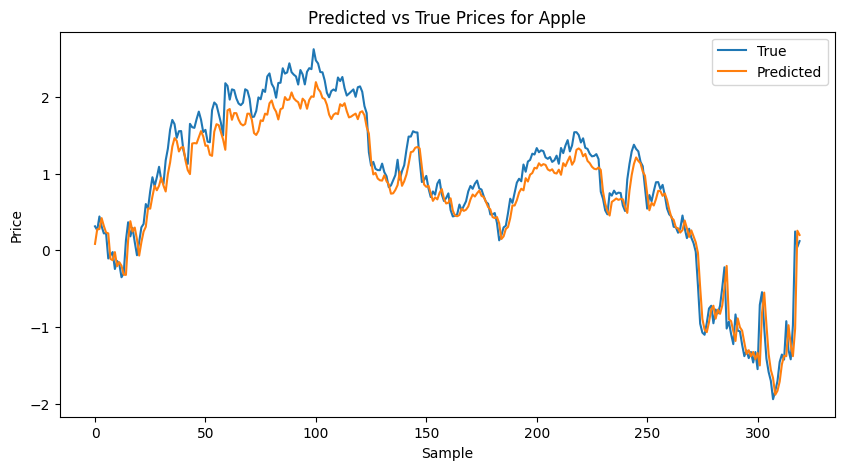

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Apple")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

### HSBC

In [38]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ,terminated_epoch = full_news_demo(
        tickers = unique_tickers,
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=5,
        co_window=5,
        batch_size=2,
        epochs=100,
        device_str="cpu",
    )

/tmp/ipykernel_666/3464771138.py:97: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow 

Price data shape: (1766, 895)
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   neutral  0.935243  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   neutral  0.934711  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   neutral  0.818104  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  positive  0.926698  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   neutral  0.701650  
Aggregating sentiment per company-day...
Sentiment df head:
            HSBC 

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:205: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


in_feats=3, dataset length=1761
Epoch 1/100 | Train Loss: 0.260919 | Val Loss: 0.103122 | Val MSE (Target Company): 0.103122
Validation improved. Best validation MSE = 0.103122
Epoch 2/100 | Train Loss: 0.096798 | Val Loss: 0.045230 | Val MSE (Target Company): 0.045230
Validation improved. Best validation MSE = 0.045230
Epoch 3/100 | Train Loss: 0.088104 | Val Loss: 0.049992 | Val MSE (Target Company): 0.049992
No improvement (1/10)
Epoch 4/100 | Train Loss: 0.089566 | Val Loss: 0.048897 | Val MSE (Target Company): 0.048897
No improvement (2/10)
Epoch 5/100 | Train Loss: 0.086183 | Val Loss: 0.055293 | Val MSE (Target Company): 0.055293
No improvement (3/10)
Epoch 6/100 | Train Loss: 0.084912 | Val Loss: 0.047949 | Val MSE (Target Company): 0.047949
No improvement (4/10)
Epoch 7/100 | Train Loss: 0.080688 | Val Loss: 0.073366 | Val MSE (Target Company): 0.073366
No improvement (5/10)
Epoch 8/100 | Train Loss: 0.080144 | Val Loss: 0.074862 | Val MSE (Target Company): 0.074862
No improve

In [47]:
import pandas as pd
from google.colab import files

pd.DataFrame(sentiment_df.columns).to_excel("unique_tickers.xlsx", index=False)

files.download("unique_tickers.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
price_df

Ticker,HSBC,EPS,AGM,PLUS,RIO,BCS,CAGR,DB,EU,EPC,...,OCGN,TWLO,EMA,IR,CFA,PSA,SSP,OBE,PDM,TEVA
Date,,,,,,,,,,,,,,,,,,,,,
2017-06-28,27.055061,23.914516,50.256458,37.027668,20.296619,7.867644,0.00010,15.077855,0.12,69.499977,...,107.400002,29.500000,25.126562,19.677107,39.097443,145.435471,13.240921,8.82,13.142215,32.437027
2017-06-29,28.194212,23.729576,49.053196,36.706760,20.626925,7.949832,0.00010,15.212553,0.12,68.079590,...,109.800003,29.000000,25.032925,19.825125,38.764771,144.136963,12.924980,8.89,12.987159,32.456799
2017-06-30,28.109388,23.709663,47.761345,36.583332,20.858633,7.912476,0.00010,14.976833,0.12,68.340302,...,107.400002,29.110001,24.945984,19.991642,38.976578,144.803558,12.788547,8.89,13.073989,32.842365
2017-07-03,28.624428,23.880375,49.311558,36.410542,21.494600,7.994660,0.00010,15.279902,0.12,68.466156,...,103.800003,28.969999,24.966047,20.666969,39.020687,147.720062,12.896255,8.47,13.284857,32.931339
2017-07-04,28.624428,23.880375,49.311558,36.410542,21.494600,7.994660,0.00010,15.279902,0.12,68.466156,...,103.800003,28.969999,24.966047,20.666969,39.020687,147.720062,12.896255,8.47,13.284857,32.931339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-01,37.775639,51.536617,176.405777,74.963737,60.108669,9.766058,0.00001,14.748254,4.75,35.647392,...,1.390000,60.950001,30.988211,92.803085,75.176514,237.899689,2.932331,8.22,6.335271,13.980000
2024-05-02,38.519897,51.953487,179.629562,75.990639,60.803253,9.747040,0.00001,14.766496,4.92,36.065319,...,1.320000,61.520000,31.244543,92.653412,75.662819,241.356415,3.172932,7.97,6.419867,14.080000
2024-05-03,38.467979,52.506081,180.437820,76.938553,61.390987,9.756549,0.00001,15.021876,4.82,35.922844,...,1.330000,61.889999,31.409323,86.536392,76.119026,243.029892,3.210526,7.98,6.495063,13.980000


In [43]:
sentiment_df.describe()

,HSBC,EPS,AGM,PLUS,RIO,BCS,CAGR,DB,EU,EPC,...,OCGN,TWLO,EMA,IR,CFA,PSA,SSP,OBE,PDM,TEVA
count,1766.000000,1766.0,1766.0,1766.0,1766.000000,1766.000000,1766.0,1766.000000,1766.0,1766.0,...,1766.0,1766.0,1766.0,1766.0,1766.0,1766.0,1766.0,1766.000000,1766.000000,1766.000000
mean,-0.006148,0.0,0.0,0.0,-0.000057,-0.002955,0.0,0.001873,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000446,0.000446,0.000446
std,0.280464,0.0,0.0,0.0,0.002412,0.144680,0.0,0.069297,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018722,0.018722,0.018722
min,-0.973055,0.0,0.0,0.0,-0.101348,-0.971924,0.0,-0.971924,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
25%,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
50%,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
75%,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
max,0.953735,0.0,0.0,0.0,0.000000,0.950963,0.0,0.934938,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.786789,0.786789,0.786789


In [44]:
sentiment_df.shape

(1766, 720)

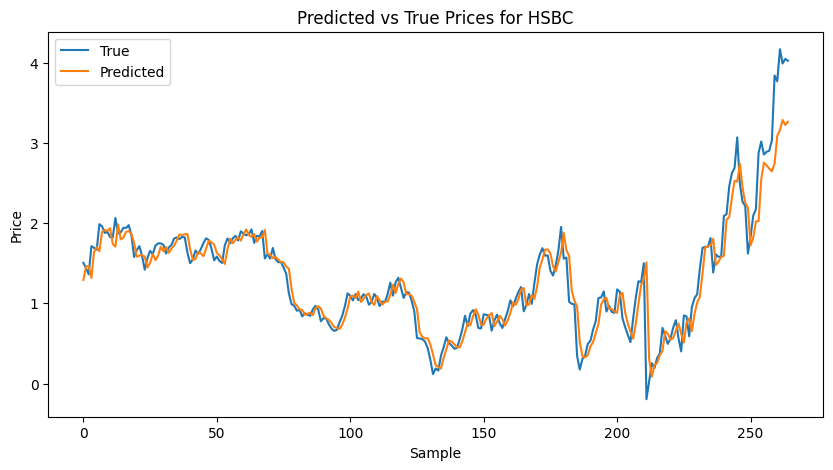

In [39]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ, label='True')
plt.plot(preds, label='Predicted')
plt.title(f"Predicted vs True Prices for HSBC")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [51]:
if __name__ == "__main__":

    import random
    import numpy as np
    import torch

    mse_list = []
    mae_list = []

    for run in range(5):

        print("\n" + "=" * 80)
        print(f"Run {run + 1}/5")
        print("=" * 80)

        # Different random seed for each run
        seed = run

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        (
            model,
            dataset,
            price_df,
            news_labeled,
            sentiment_df,
            preds,
            targ,
            terminated_epoch,
            test_metrics,
        ) = full_news_demo(
            tickers=unique_tickers,
            start_date=apple_data["date"].min(),
            end_date=apple_data["date"].max(),
            n_news=len(apple_data),
            seq_len=5,
            co_window=5,
            batch_size=8,
            epochs=100,        # Use a large maximum if early stopping is enabled
            device_str="cpu",
        )

        mse_list.append(test_metrics["mse"])
        mae_list.append(test_metrics["mae"])

        print(f"Run {run + 1} Results")
        print(f"MSE = {test_metrics['mse']:.6f}")
        print(f"MAE = {test_metrics['mae']:.6f}")

    mse_mean = np.mean(mse_list)
    mse_std = np.std(mse_list, ddof=1)

    mae_mean = np.mean(mae_list)
    mae_std = np.std(mae_list, ddof=1)

    print("\n" + "=" * 80)
    print("Overall Results (5 Runs)")
    print("=" * 80)

    print(f"MSE : {mse_mean:.6f} ± {mse_std:.6f}")
    print(f"MAE : {mae_mean:.6f} ± {mae_std:.6f}")


Run 1/5


/tmp/ipykernel_666/3240773297.py:97: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow 

Price data shape: (1766, 720)
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   neutral  0.935243  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   neutral  0.934711  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   neutral  0.818104  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  positive  0.926698  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   neutral  0.701650  
Aggregating sentiment per company-day...
Sentiment df head:
            HSBC 

...

Price data shape: (1766, 720)
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08              HSBC Holdings PLC's Dividend Analysis   
1  2024-05-06  Top Three UK Dividend Stocks To Watch In May 2024   
2  2024-05-04  Ping An votes against reappointment of HSBC CE...   
3  2024-05-04  HSBC Holdings First Quarter 2024 Earnings: Bea...   
4  2024-05-03  3 Foreign Bank Stocks Worth a Look in a Prospe...   

                                            mentions     label     score  
0  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...   neutral  0.935243  
1  ['0005.HK', 'BYG.LSE', 'DCC.LSE', 'GFTU.LSE', ...   neutral  0.934711  
2  ['0005.HK', '2318.HK', '601318.SHG', 'H1SB34.S...   neutral  0.818104  
3  ['0005.HK', 'H1SB34.SA', 'HBC1.BE', 'HBC1.DU',...  positive  0.926698  
4  ['0005.HK', 'GSPC.INDX', 'H1SB34.SA', 'HBC1.BE...   neutral  0.701650  
Aggregating sentiment per company-day...
Sentiment df head:
            HSBC 

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:194: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:205: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


in_feats=3, dataset length=1761
Epoch 1/100 | Train Loss: 0.478909 | Val Loss: 0.090204 | Val MSE (Target Company): 0.090204
Validation improved. Best validation MSE = 0.090204
Epoch 2/100 | Train Loss: 0.098253 | Val Loss: 0.050504 | Val MSE (Target Company): 0.050504
Validation improved. Best validation MSE = 0.050504
Epoch 3/100 | Train Loss: 0.084341 | Val Loss: 0.045515 | Val MSE (Target Company): 0.045515
Validation improved. Best validation MSE = 0.045515
Epoch 4/100 | Train Loss: 0.079466 | Val Loss: 0.061903 | Val MSE (Target Company): 0.061903
No improvement (1/10)
Epoch 5/100 | Train Loss: 0.083971 | Val Loss: 0.050207 | Val MSE (Target Company): 0.050207
No improvement (2/10)
Epoch 6/100 | Train Loss: 0.077158 | Val Loss: 0.052227 | Val MSE (Target Company): 0.052227
No improvement (3/10)
Epoch 7/100 | Train Loss: 0.073058 | Val Loss: 0.048169 | Val MSE (Target Company): 0.048169
No improvement (4/10)
Epoch 8/100 | Train Loss: 0.079725 | Val Loss: 0.048132 | Val MSE (Target

### Pepsi

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ,terminated_epoch = full_news_demo(
        tickers = unique_tickers,
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=5,
        co_window=5,
        batch_size=8,
        epochs=100,
        device_str="cpu",
    )

/tmp/ipykernel_1282/3611805377.py:97: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Removed 0 invalid tickers:
[]
Using tickers: ['PEP', 'KO', 'MNST', 'KDP', 'STZ', 'BF-B', 'PG', 'CL', 'UL', 'NSRGY', 'MDLZ', 'GIS', 'HSY', 'SJM', 'KHC', 'CPB', 'CAG', 'ADM', 'BG', 'WMT', 'COST', 'TGT', 'KR', 'SYY', 'MCD', 'YUM', 'CMG', 'DPZ', 'SBUX', 'NKE', 'AAPL', 'MSFT', 'AMZN', 'TSLA', 'NVDA', 'DIS', 'NFLX', 'META', 'GOOGL', 'IBM', 'INTC', 'CVX', 'XOM', 'BP', 'PFE', 'JNJ', 'MRK', 'ABT', 'ABBV']
Length of tickers: 49
Price data shape: (2145, 49)
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  positive  0.929564  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   neutral  0.894171  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   neutral  0.568550  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  positive  0.932543  
4                               ['JNJ.US', 'PEP.US']  positive  0.929564  
Aggregating sentiment per company-day...
Sentiment df head:
                 

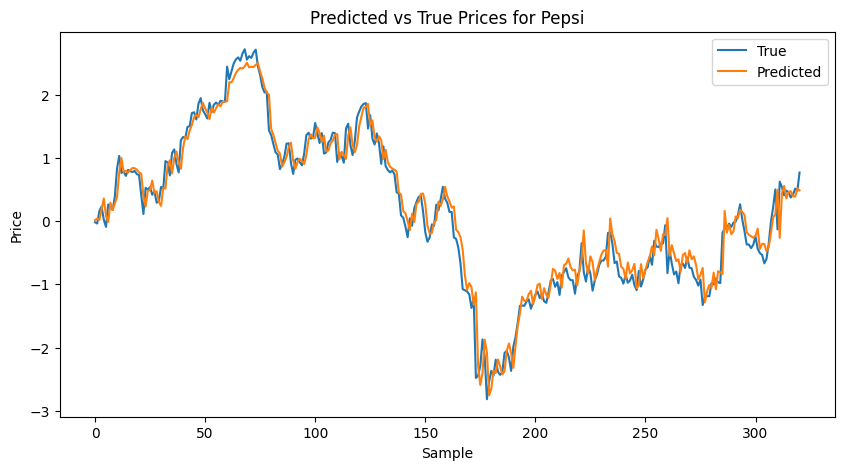

In [ ]:
import matplotlib.pyplot as plt

# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ, label='True')
plt.plot(preds, label='Predicted')
plt.title(f"Predicted vs True Prices for Pepsi")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":

    import random
    import numpy as np
    import torch

    mse_list = []
    mae_list = []

    for run in range(5):

        print("\n" + "=" * 80)
        print(f"Run {run + 1}/5")
        print("=" * 80)

        # Different random seed for each run
        seed = run

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        (
            model,
            dataset,
            price_df,
            news_labeled,
            sentiment_df,
            preds,
            targ,
            test_metrics,
        ) = full_news_demo(
            tickers = unique_tickers,
            start_date=apple_data["date"].min(),
            end_date=apple_data["date"].max(),
            n_news=len(apple_data),
            seq_len=5,
            co_window=5,
            batch_size=8,
            epochs=5,        # Use a large maximum if early stopping is enabled
            device_str="cpu",
        )

        mse_list.append(test_metrics["mse"])
        mae_list.append(test_metrics["mae"])

        print(f"Run {run + 1} Results")
        print(f"MSE = {test_metrics['mse']:.6f}")
        print(f"MAE = {test_metrics['mae']:.6f}")

    mse_mean = np.mean(mse_list)
    mse_std = np.std(mse_list, ddof=1)

    mae_mean = np.mean(mae_list)
    mae_std = np.std(mae_list, ddof=1)

    print("\n" + "=" * 80)
    print("Overall Results (5 Runs)")
    print("=" * 80)

    print(f"MSE : {mse_mean:.6f} ± {mse_std:.6f}")
    print(f"MAE : {mae_mean:.6f} ± {mae_std:.6f}")


Run 1/5


/tmp/ipykernel_1041/2743029825.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Price data shape: (2145, 49)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  positive  0.929564  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   neutral  0.894171  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   neutral  0.568550  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  positive  0.932543  
4                               ['JNJ.US', 'PEP.US']  positive  0.929564  
Aggregating sentiment per company-day...
Sentiment df head:
                 

...

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  positive  0.929564  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   neutral  0.894171  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   neutral  0.568550  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  positive  0.932543  
4                               ['JNJ.US', 'PEP.US']  positive  0.929564  
Aggregating sentiment per company-day...
Sentiment df head:
                 

/tmp/ipykernel_1041/2743029825.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Price data shape: (2145, 49)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  positive  0.929564  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   neutral  0.894171  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   neutral  0.568550  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  positive  0.932543  
4                               ['JNJ.US', 'PEP.US']  positive  0.929564  
Aggregating sentiment per company-day...
Sentiment df head:
                 

### Toyota

In [ ]:
if __name__ == "__main__":
    # Quick run (may download models & price data)
    model, dataset, price_df, news_labeled, sentiment_df, preds, targ, terminated_epoch = full_news_demo(
        tickers = unique_tickers,
        start_date=apple_data["date"].min(),
        end_date=apple_data["date"].max(),
        n_news=len(apple_data),
        seq_len=5,
        co_window=5,
        batch_size=32,
        epochs=100,
        device_str="cpu",
    )

/tmp/ipykernel_1282/3611805377.py:97: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Removed 0 invalid tickers:
[]
Using tickers: ['7203.T', '7201.T', '7267.T', '7261.T', '7269.T', '6902.T', '7202.T', '7270.T', '7272.T', 'TSLA', 'F', 'GM', 'VOW3.DE', 'BMW.DE', 'MBG.DE', 'STLA', 'HMC', '005380.KS', '000270.KS', '1211.HK', '0175.HK', '2333.HK', 'BYDDF', 'BYDDY', 'AAPL', 'NVDA', 'INTC', 'AMD', 'QCOM', 'TSM', '7269.T', 'TM', 'GM', 'F', 'AAPL', 'AMZN', 'MSFT', 'GOOGL', 'META', 'BABA', 'JD']
Length of tickers: 41
Price data shape: (2249, 41)
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  negative  0.831539  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   neutral  0.589369  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   neutral  0.940713  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  negative  0.970002  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  positive  0.918822  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

In [ ]:
import matplotlib.pyplot as plt

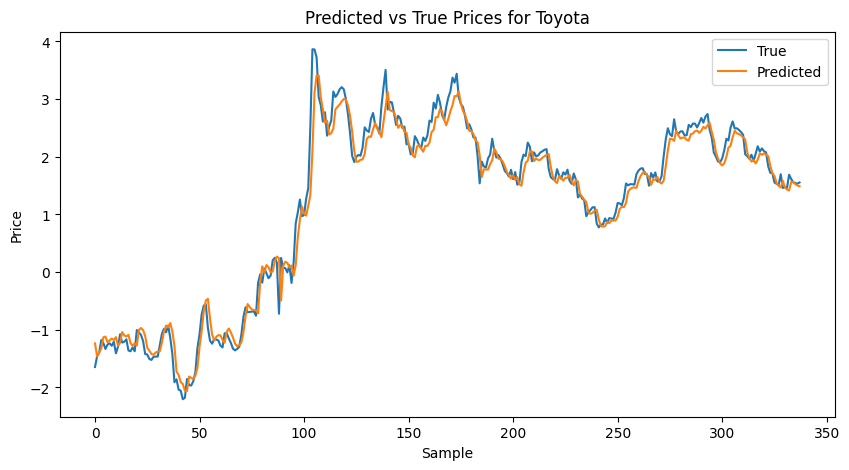

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Toyota")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":

    import random
    import numpy as np
    import torch

    mse_list = []
    mae_list = []

    for run in range(5):

        print("\n" + "=" * 80)
        print(f"Run {run + 1}/5")
        print("=" * 80)

        # Different random seed for each run
        seed = run

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        (
            model,
            dataset,
            price_df,
            news_labeled,
            sentiment_df,
            preds,
            targ,
            test_metrics,
        ) = full_news_demo(
            tickers = tickers,
            start_date=apple_data["date"].min(),
            end_date=apple_data["date"].max(),
            n_news=len(apple_data),
            seq_len=5,
            co_window=5,
            batch_size=8,
            epochs=5,        # Use a large maximum if early stopping is enabled
            device_str="cpu",
        )

        mse_list.append(test_metrics["mse"])
        mae_list.append(test_metrics["mae"])

        print(f"Run {run + 1} Results")
        print(f"MSE = {test_metrics['mse']:.6f}")
        print(f"MAE = {test_metrics['mae']:.6f}")

    mse_mean = np.mean(mse_list)
    mse_std = np.std(mse_list, ddof=1)

    mae_mean = np.mean(mae_list)
    mae_std = np.std(mae_list, ddof=1)

    print("\n" + "=" * 80)
    print("Overall Results (5 Runs)")
    print("=" * 80)

    print(f"MSE : {mse_mean:.6f} ± {mse_std:.6f}")
    print(f"MAE : {mae_mean:.6f} ± {mae_std:.6f}")


Run 1/5


/tmp/ipykernel_1041/61774552.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow i

Price data shape: (2249, 41)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  negative  0.831539  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   neutral  0.589369  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   neutral  0.940713  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  negative  0.970002  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  positive  0.918822  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

...

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  negative  0.831539  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   neutral  0.589369  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   neutral  0.940713  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  negative  0.970002  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  positive  0.918822  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

/tmp/ipykernel_1041/61774552.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow i

Price data shape: (2249, 41)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Toyota issues muted profit forecast following ...   
1  2024-05-08  Every household should be forced to have a sma...   
2  2024-05-08  Trending tickers: Apple, Reddit, JD Wetherspoo...   
3  2024-05-08  Toyota Motor Projects Drop in Fiscal-Year Prof...   
4  2024-05-08  Toyota racks up booming profit, vows to invest...   

                                            mentions     label     score  
0  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TMN.MX', '...  negative  0.831539  
1  ['1BMW.MI', '2330.TW', '7203.TSE', '9984.TSE',...   neutral  0.589369  
2  ['7203.TSE', 'ARM.US', 'TM.US', 'TMCO34.SA', '...   neutral  0.940713  
3  ['6201.TSE', '7203.TSE', 'TAH.F', 'TM.US', 'TM...  negative  0.970002  
4  ['7203.TSE', 'TM.US', 'TMCO34.SA', 'TOM.BE', '...  positive  0.918822  
Aggregating sentiment per company-day...
Sentiment df head:
            7203.

### Tencent

In [ ]:
import matplotlib.pyplot as plt

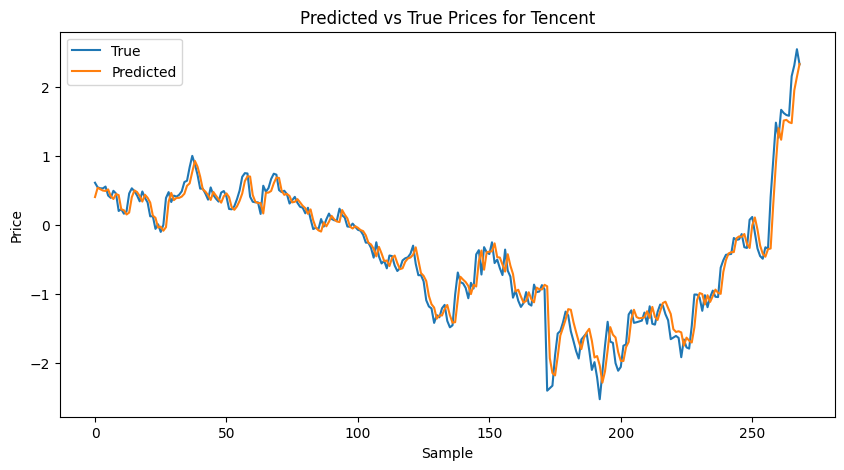

In [ ]:
# Assume preds and targ have shape (num_samples, num_companies)
company_idx = 0  # Apple
plt.figure(figsize=(10, 5))
plt.plot(targ[:, company_idx], label='True')
plt.plot(preds[:, company_idx], label='Predicted')
plt.title(f"Predicted vs True Prices for Tencent")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
if __name__ == "__main__":

    import random
    import numpy as np
    import torch

    mse_list = []
    mae_list = []

    for run in range(5):

        print("\n" + "=" * 80)
        print(f"Run {run + 1}/5")
        print("=" * 80)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        (
            model,
            dataset,
            price_df,
            news_labeled,
            sentiment_df,
            preds,
            targ,
            test_metrics,
        ) = full_news_demo(
        tickers = unique_tickers,
            start_date=apple_data["date"].min(),
            end_date=apple_data["date"].max(),
            n_news=len(apple_data),
            seq_len=5,
            co_window=5,
            batch_size=8,
            epochs=5,        # Use a large maximum if early stopping is enabled
            device_str="cpu",
        )

        mse_list.append(test_metrics["mse"])
        mae_list.append(test_metrics["mae"])

        print(f"Run {run + 1} Results")
        print(f"MSE = {test_metrics['mse']:.6f}")
        print(f"MAE = {test_metrics['mae']:.6f}")

    mse_mean = np.mean(mse_list)
    mse_std = np.std(mse_list, ddof=1)

    mae_mean = np.mean(mae_list)
    mae_std = np.std(mae_list, ddof=1)

    print("\n" + "=" * 80)
    print("Overall Results (5 Runs)")
    print("=" * 80)

    print(f"MSE : {mse_mean:.6f} ± {mse_std:.6f}")
    print(f"MAE : {mae_mean:.6f} ± {mae_std:.6f}")


Run 1/5


/tmp/ipykernel_1041/2743029825.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Price data shape: (1795, 33)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Tencent, Alibaba Earnings Are Key to Longer Ch...   
1  2024-05-07  The 3 Most Undervalued Chinese Stocks to Buy i...   
2  2024-05-04  Stock Market Crash Alert: 3 Must-Buy Social Me...   
3  2024-05-03  3 Under-The-Radar Stocks That Could Be Worth O...   
4  2024-04-30  Alibaba Stock Analysis: Why BABA Is a China Be...   

                                            mentions     label     score  
0  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...  positive  0.675000  
1  ['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...   neutral  0.737658  
2  ['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...   neutral  0.780156  
3  ['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...   neutral  0.906766  
4  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   neutral  0.924205  
Aggregating sentiment per company-day...
Sentiment df head:
            0700.

...

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Tencent, Alibaba Earnings Are Key to Longer Ch...   
1  2024-05-07  The 3 Most Undervalued Chinese Stocks to Buy i...   
2  2024-05-04  Stock Market Crash Alert: 3 Must-Buy Social Me...   
3  2024-05-03  3 Under-The-Radar Stocks That Could Be Worth O...   
4  2024-04-30  Alibaba Stock Analysis: Why BABA Is a China Be...   

                                            mentions     label     score  
0  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...  positive  0.675000  
1  ['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...   neutral  0.737658  
2  ['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...   neutral  0.780156  
3  ['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...   neutral  0.906766  
4  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   neutral  0.924205  
Aggregating sentiment per company-day...
Sentiment df head:
            0700.

/tmp/ipykernel_1041/2743029825.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow

Price data shape: (1795, 33)
Generating synthetic news...
Loading FinBERT pipeline (this may take a while for first run)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Classifying synthetic news with FinBERT...
Sample labeled news:
         date                                              title  \
0  2024-05-08  Tencent, Alibaba Earnings Are Key to Longer Ch...   
1  2024-05-07  The 3 Most Undervalued Chinese Stocks to Buy i...   
2  2024-05-04  Stock Market Crash Alert: 3 Must-Buy Social Me...   
3  2024-05-03  3 Under-The-Radar Stocks That Could Be Worth O...   
4  2024-04-30  Alibaba Stock Analysis: Why BABA Is a China Be...   

                                            mentions     label     score  
0  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...  positive  0.675000  
1  ['0700.HK', '9888.HK', 'B1C.F', 'B1C.STU', 'B1...   neutral  0.737658  
2  ['0700.HK', 'DJT.US', 'META.US', 'NNN1.BE', 'N...   neutral  0.780156  
3  ['0700.HK', '0YXG.LSE', '1YD.BE', '1YD.DU', '1...   neutral  0.906766  
4  ['0700.HK', '2RR.F', '9988.HK', 'AHLA.F', 'AHL...   neutral  0.924205  
Aggregating sentiment per company-day...
Sentiment df head:
            0700.